# Funcoes de pertinencia do fuzzy threshold

Notebook temporario para gerar uma figura em 300 dpi representando as tres classes do fuzzy threshold: fundo mole, objeto e fundo denso. Os centros de objeto e fundo denso sao estimados pela media dos percentis 99.5 e 99.7 no conjunto de teste.

In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    """Resolve a raiz do repo a partir do diretorio atual do notebook."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "config" / "pipeline_config.json").exists():
            return candidate
    raise FileNotFoundError("Nao foi possivel encontrar config/pipeline_config.json")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.project.dataset import get_data_splits
from utils.project.notebook_env import resolve_imagecas_base_path
from utils.processing.preprocessing import downscale_image
from utils.utils.nifti_io import load_raw_img_and_label

CONFIG_PATH = REPO_ROOT / "config" / "pipeline_config.json"
OUTPUT_DIR = REPO_ROOT / "output" / "segmentation" / "analysis" / "fuzzy_membership_functions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with CONFIG_PATH.open("r", encoding="utf-8") as file_handle:
    CONFIG = json.load(file_handle)

MIN_HU = float(CONFIG.get("MIN_THRESHOLD", -300))
DOWNSCALE_FACTORS = tuple(CONFIG.get("DOWNSCALE_FACTORS", [2, 2, 1]))
USE_OPENCV = CONFIG.get("DOWNSCALE_METHOD", "opencv") == "opencv"
OPENCV_INTERPOLATION = getattr(cv2, f"INTER_{CONFIG.get('OPENCV_INTERPOLATION', 'linear').upper()}", cv2.INTER_LINEAR)
FUZZY_CONFIG = CONFIG.get("THRESHOLDING", {}).get("fuzzy", {})
SOFT_MARGIN_HU = float(FUZZY_CONFIG.get("soft_margin_hu", 160))

OBJECT_PERCENTILE = 99.5
DENSE_PERCENTILE = 99.7
MAX_TEST_IMAGES = 60

BASE_PATH = resolve_imagecas_base_path()
print(f"Dataset: {BASE_PATH}")

Dataset: /media/matheus/HD/DatasetsCCTA/ImageCAS/1-1000


## Centros das classes

Para evitar empilhar todos os voxels do teste em memoria, os percentis sao calculados por imagem depois do downscale do pipeline e depois agregados pela media. O numero de imagens usadas e controlado por `MAX_TEST_IMAGES`.

In [2]:
_, _, test_ids, _ = get_data_splits(str(BASE_PATH))
if MAX_TEST_IMAGES is not None:
    test_ids = test_ids[: int(MAX_TEST_IMAGES)]
print(f"Usando {len(test_ids)} imagens do conjunto de teste")
print(f"Downscale factors: {DOWNSCALE_FACTORS} | OpenCV: {USE_OPENCV}")

rows = []
for index, img_id in enumerate(test_ids, start=1):
    img_path = BASE_PATH / f"{img_id}.img.nii.gz"
    nii_img, _ = load_raw_img_and_label(str(img_path))
    volume = np.asarray(nii_img.get_fdata(dtype=np.float32), dtype=np.float32)
    down_volume = downscale_image(
        volume,
        DOWNSCALE_FACTORS,
        order=3,
        use_opencv=USE_OPENCV,
        opencv_interpolation=OPENCV_INTERPOLATION,
    )
    values = down_volume[np.isfinite(down_volume)]
    valid_values = values[values >= MIN_HU]
    if valid_values.size == 0:
        valid_values = values

    rows.append(
        {
            "IMG_ID": int(img_id),
            "p99_5_hu": float(np.percentile(valid_values, OBJECT_PERCENTILE)),
            "p99_7_hu": float(np.percentile(valid_values, DENSE_PERCENTILE)),
            "n_valid_voxels": int(valid_values.size),
        }
    )

    if index % 50 == 0 or index == len(test_ids):
        print(f"Processadas {index}/{len(test_ids)} imagens")

percentiles_df = pd.DataFrame(rows)
percentiles_df.head()

Usando 60 imagens do conjunto de teste
Downscale factors: (2, 2, 1) | OpenCV: True
Processadas 50/60 imagens
Processadas 60/60 imagens


,IMG_ID,p99_5_hu,p99_7_hu,n_valid_voxels
0,568,492.00,507.00,9485867
1,762,633.50,713.75,12388514
2,765,715.75,839.00,11302349
3,693,590.50,685.50,9558023
4,469,864.00,958.00,9852199


In [3]:
soft_center = MIN_HU - SOFT_MARGIN_HU
object_center = float(percentiles_df["p99_5_hu"].mean())
dense_center = float(percentiles_df["p99_7_hu"].mean())

centers_df = pd.DataFrame(
    [
        {"classe": "fundo mole", "centro_hu": soft_center, "origem": f"MIN_HU - {SOFT_MARGIN_HU:g} HU"},
        {"classe": "objeto", "centro_hu": object_center, "origem": f"media do P{OBJECT_PERCENTILE:g} no teste"},
        {"classe": "fundo denso", "centro_hu": dense_center, "origem": f"media do P{DENSE_PERCENTILE:g} no teste"},
    ]
)
centers_df

,classe,centro_hu,origem
0,fundo mole,-460.000000,MIN_HU - 160 HU
1,objeto,722.116667,media do P99.5 no teste
2,fundo denso,795.834763,media do P99.7 no teste


## Figura 300 dpi

As curvas abaixo seguem a mesma logica implementada no pipeline: fundo mole decresce ate `MIN_HU`, fundo denso cresce entre o centro de objeto e o centro denso, e objeto fica alto na regiao intermediaria. Depois as pertinencias sao normalizadas para somarem 1 em cada HU.

Figura salva em: /home/matheus/workspace/coronary-centerline-detection/output/segmentation/analysis/fuzzy_membership_functions/fuzzy_membership_functions_test_mean_p995_p997_300dpi.png


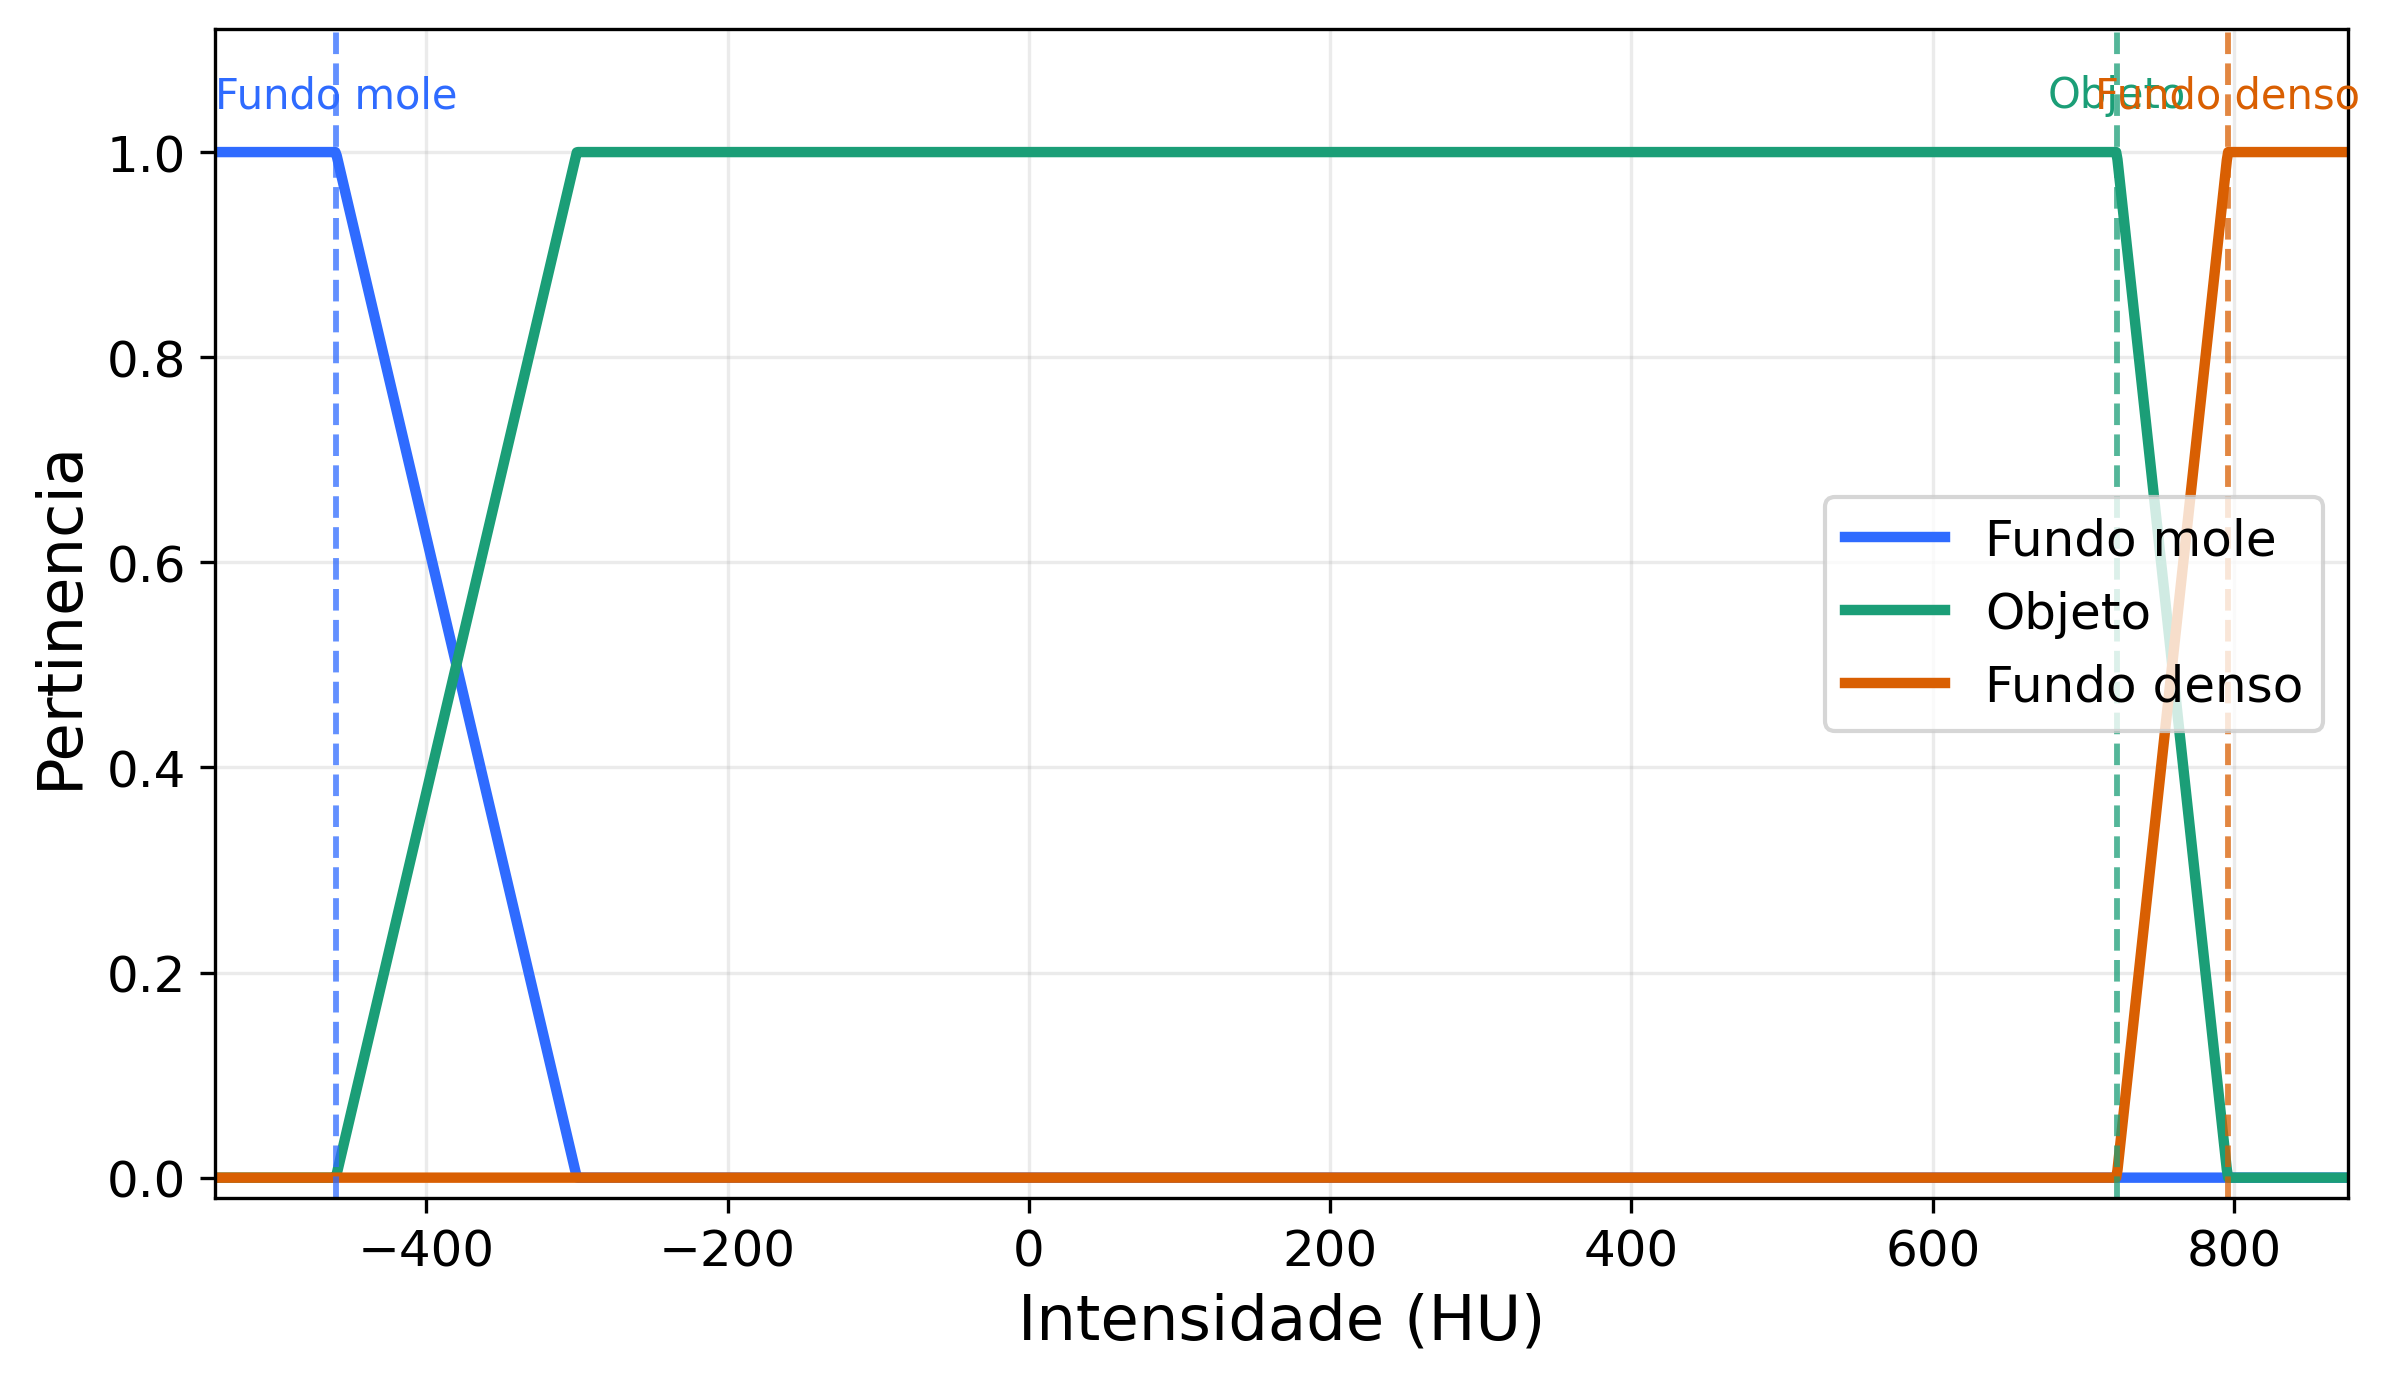

In [4]:
soft_width = max(MIN_HU - soft_center, np.finfo(np.float32).eps)
dense_width = max(dense_center - object_center, np.finfo(np.float32).eps)

x_min = soft_center - 80
x_max = dense_center + 80
hu_values = np.linspace(x_min, x_max, 1600, dtype=np.float32)

mu_soft = np.clip((MIN_HU - hu_values) / soft_width, 0.0, 1.0)
mu_dense = np.clip((hu_values - object_center) / dense_width, 0.0, 1.0)
mu_object = np.minimum(1.0 - mu_soft, 1.0 - mu_dense)

memberships = np.vstack([mu_soft, mu_object, mu_dense])
memberships = memberships / np.maximum(memberships.sum(axis=0, keepdims=True), np.finfo(np.float32).eps)
mu_soft_norm, mu_object_norm, mu_dense_norm = memberships

plt.rcParams.update(
    {
        "font.size": 13,
        "axes.labelsize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

fig, ax = plt.subplots(figsize=(8.2, 4.8), dpi=300)
ax.plot(hu_values, mu_soft_norm, linewidth=2.5, color="#2F6BFF", label="Fundo mole")
ax.plot(hu_values, mu_object_norm, linewidth=2.5, color="#1B9E77", label="Objeto")
ax.plot(hu_values, mu_dense_norm, linewidth=2.5, color="#D95F02", label="Fundo denso")

center_lines = [
    (soft_center, "Fundo mole", "#2F6BFF"),
    (object_center, "Objeto", "#1B9E77"),
    (dense_center, "Fundo denso", "#D95F02"),
]
for center, label, color in center_lines:
    ax.axvline(center, linestyle="--", linewidth=1.4, color=color, alpha=0.75)
    ax.text(center, 1.035, label, color=color, ha="center", va="bottom", rotation=0, fontsize=10)

ax.set_xlabel("Intensidade (HU)")
ax.set_ylabel("Pertinencia")
ax.set_ylim(-0.02, 1.12)
ax.set_xlim(x_min, x_max)
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(loc="center right", frameon=True)
fig.tight_layout()

figure_path = OUTPUT_DIR / "fuzzy_membership_functions_test_mean_p995_p997_300dpi.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"Figura salva em: {figure_path}")
plt.show()

In [5]:
summary_path = OUTPUT_DIR / "fuzzy_membership_centers_test_mean_p995_p997.csv"
centers_df.to_csv(summary_path, index=False)
print(f"Resumo dos centros salvo em: {summary_path}")

Resumo dos centros salvo em: /home/matheus/workspace/coronary-centerline-detection/output/segmentation/analysis/fuzzy_membership_functions/fuzzy_membership_centers_test_mean_p995_p997.csv
